# 309.3. Extendedness parameter

<div style="max-width:300px; float: left; margin-right: 1em">

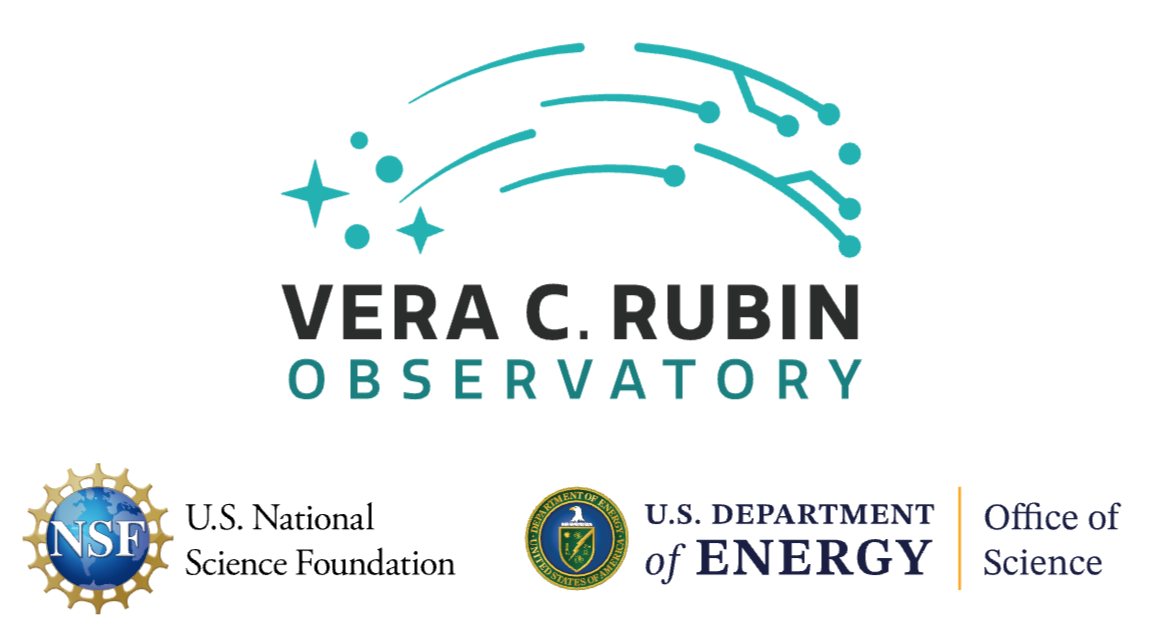

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Data Release: [Data Preview 1](https://dp1.lsst.io)\
Container Size: large\
LSST Science Pipelines version: r29.2.0\
Last verified to run: 2026-04-08\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** To explore the DP1 extendedness parameters.

**LSST data products:** `Object`

**Packages:** `lsst.rsp`

**Credit:**
Originally developed by the Rubin Community Science team. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the 
<a href="https://community.lsst.org/c/support">Support Category</a> 
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

In astronomical photometric surveys like the Vera C. Rubin Observatory’s Legacy Survey of Space and Time (LSST), the robust separation of point-like sources (stars) from extended sources (galaxies) is a foundational step for most downstream science.

In Data Preview 1 (DP1), this morphological classification is primarily driven by two complementary methodologies:
- Flux-based extendedness: Utilizes the ratio between Point Spread Function (PSF) and Composite model (CModel) fluxes to determine if a source’s profile is consistent with the local Point Spread Function.
- Size-based extendedness: Leverages shape-based parameters (adaptive second moments) to quantify the spatial extent of a source relative to the PSF.

This tutorial illustrates the computation of these parameters in DP1, demonstrates their characteristics, and explores their relative performance using observations of the Fornax dSph field.

**References:** [RTN-095](https://rtn-095.lsst.io/).

**Related tutorials:** See the 300-level DP1 tutorial on galaxy photometry and shapes.

### 1.1. Import packages

Import `numpy`, a fundamental package for scientific computing with arrays in Python
(<a href="https://numpy.org">numpy.org</a>), 
and `matplotlib`, a comprehensive library for data visualization
(<a href="https://matplotlib.org/">matplotlib.org</a>;
<a href="https://matplotlib.org/stable/gallery/index.html">matplotlib gallery</a>).

From the LSST pacakge (<a href="https://pipelines.lsst.io/">pipelines.lsst.io</a>), import the RSP Table Access Protocol (TAP) service.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patheffects as path_effects

from lsst.rsp import get_tap_service

### 1.2. Define parameters and functions

Create an instance of the TAP service, and assert that it exists.

In [2]:
rsp_tap = get_tap_service("tap")
assert rsp_tap is not None

Define a 1-degree radius around the central point of the Fornax dSph field.

In [3]:
ra_cen = 40.080
dec_cen = -34.450
radius = 1.0

List bands available in the field.

In [4]:
bands = "gri"

Set font sizes globally for all subsequent matplotlib figures in this notebook.

In [5]:
plt.rcParams["font.size"] = 15
plt.rcParams["figure.titlesize"] = 15
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.titlesize"] = 12

Define a function to generate a 2D density map comparing two sets of variables. The function calculates the population density of each cell and overlays the percentage of the total sample using high-contrasts text annotations. 

In [6]:
def plot_density_comparison(data, x_cols, y_cols, n_bins=5, sharey=True, figsize=None):
    """
    Creates a grid of 2D density maps with percentage annotations.
    
    Parameters:
    -----------
    data : array-like or Table
        The dataset containing the columns.
    x_cols : list of str
        Column names for the x-axis (one per subplot).
    y_cols : list of str
        Column names for the y-axis (one per subplot).
    n_bins : int
        Number of bins for the NxN grid (default is 5).
    sharey : boolean, optional
        If True, the subplots will share the y-axis. Defaults to True.
    figsize : tuple, optional
        Figure size. Defaults to (4 * number of plots, 4).
    """
    n_plots = len(x_cols)
    if figsize is None:
        figsize = (4 * n_plots, 4)
        
    fig, axes = plt.subplots(1, n_plots, figsize=figsize, sharey=sharey)
    
    if n_plots == 1:
        axes = [axes]
        
    bin_edges = np.linspace(0, 1, n_bins + 1)

    for i, ax in enumerate(axes):
        x_name = x_cols[i]
        y_name = y_cols[i]
        
        x_data = data[x_name]
        y_data = data[y_name]
        
        h, x_edges, y_edges, im = ax.hist2d(x_data, y_data, bins=bin_edges, 
                                            range=((0, 1), (0, 1)), 
                                            norm=LogNorm(), cmap='Blues')
        
        total = len(x_data.compressed()) if hasattr(x_data, 'mask') else len(x_data)
        
        for ix in range(n_bins):
            for iy in range(n_bins):
                count = h[ix, iy]
                if count > 0:
                    pct = (count / total) * 100
                    x_center = (x_edges[ix] + x_edges[ix+1]) / 2
                    y_center = (y_edges[iy] + y_edges[iy+1]) / 2
                    
                    txt = ax.text(x_center, y_center, f'{pct:.1f}%', 
                                  color='black', ha='center', va='center', 
                                  fontsize=10, fontweight='bold')
                    txt.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])

        ax.set_xlabel(x_name)
        ax.set_xticks(bin_edges)
        ax.set_yticks(bin_edges)

        if sharey:
            if i == 0:
                ax.set_ylabel(y_name)
        else:
            ax.set_ylabel(y_name)

    plt.tight_layout()
    
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), pad=0.02)
    cbar.set_label('Source Density')
    
    return fig, axes

## 2. Query `Object` table

Query the `Object` table for coordinates, magnitudes, free-centroid flux measurements, and extendedness parameters, selecting sources with a signal-to-noise ratio greater than 5 in each of the $g,r,i$ bands.

In [7]:
query = """
        SELECT coord_ra, coord_dec,
        g_psfMag, r_psfMag, i_psfMag,
        g_free_psfFlux, r_free_psfFlux, i_free_psfFlux,
        g_cModelMag, r_cModelMag, i_cModelMag,
        g_free_cModelFlux, r_free_cModelFlux, i_free_cModelFlux,
        g_extendedness, r_extendedness, i_extendedness,
        g_sizeExtendedness, r_sizeExtendedness, i_sizeExtendedness,
        refExtendedness, refSizeExtendedness
        FROM dp1.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), 
              CIRCLE('ICRS', {}, {}, {})) = 1
              AND g_free_psfFlux/g_free_psfFluxErr > 5
              AND r_free_psfFlux/r_free_psfFluxErr > 5
              AND i_free_psfFlux/i_free_psfFluxErr > 5
              AND g_free_cModelFlux/g_free_cModelFluxErr > 5
              AND r_free_cModelFlux/r_free_cModelFluxErr > 5
              AND i_free_cModelFlux/i_free_cModelFluxErr > 5
        """.format(ra_cen, dec_cen, radius)

In [8]:
job = rsp_tap.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

Job phase is COMPLETED


Fetch the results and store them as a table.

In [9]:
assert job.phase == 'COMPLETED'
table = job.fetch_result().to_table()
print(f"The query returned {len(table)} objects.")

The query returned 74784 objects.


Option to display the table of results.

In [10]:
# table

## 3. Explore extendedness parameters

DP1 provides two types of extendedness parameters: one derived from the flux ratio and the other based on the size ratio. This section explores the characteristics of these parameters. 

### 3.1. Flux-based extendedness

The LSST Science Pipelines distinguish stars from galaxies by comparing two different flux measurements for every detected object:
- PSF flux: The flux measured by fitting the PSF model to the source. This model assumes the source is unresolved.
- CModel flux: The flux measured by fitting a "Composite Model". This model allows for the source to be extended.

For a star, the object is unresolved, meaning the PSF flux captures the same amount of light as the composite model, and the ratio is close to unity. For a galaxy, the object is extended, so the PSF fit fails to capture flux in the wings, causing the PSF flux to be significantly lower than the cModel flux. The pipeline applies a configurable threshold to this ratio to assign a binary flag. If the ratio PSF Flux/CModel Flux is greater than or equal to 0.985, the `extendedness` parameter is set to 0, indicating a star. Conversely, if the ratio is less than 0.985, the parameter is set to 1, indicating a galaxy.

#### 3.1.1. Extendedness vs. flux ratio per band

The `extendedness` parameter plotted against the PSF-to-cModel flux ratio for the $g,r,i$ bands. 

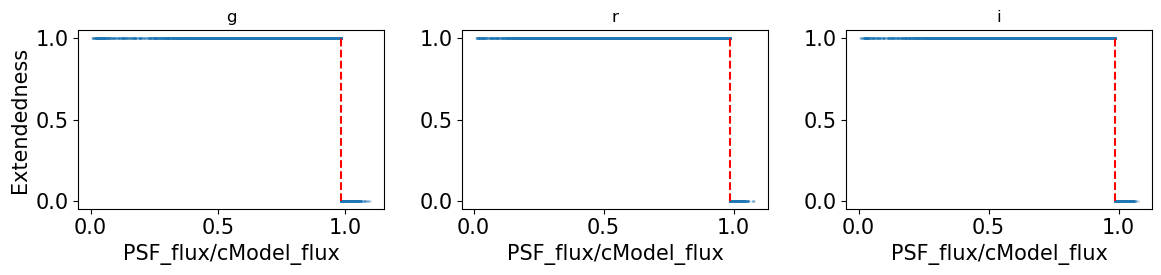

In [11]:
fig, axes = plt.subplots(1,3, figsize=(12, 3))

for band, ax in zip(bands, axes.flatten()):
    ax.scatter(table[f'{band}_free_psfFlux']/table[f'{band}_free_cModelFlux'],
               table[f'{band}_extendedness'], s=1, alpha=0.2)
    ax.plot([0.985, 0.985], [0, 1], 'r--')
    ax.set_title(f'{band}')
    ax.set_xlabel('PSF_flux/cModel_flux')
    if band == 'g':
        ax.set_ylabel('Extendedness')
    
plt.tight_layout()
plt.show()

> **Figure 1:** Distribution of the PSF-to-cModel flux ratio across the $g,r,i$ bands. The vertical red dashed line indicates the threshold at 0.985 used for morphological classification in DP1. Sources with a ratio $\ge$0.985 are classified as point-like (`extendedness` = 0), while those below this value are classified as extended (`extendedness` = 1).

#### 3.1.2. Comparison with `refExtendedness`

The `extendedness` parameter is measured both for individual bands and for a designated reference band. For each object, the reference band is selected based on detection significance and measurement quality, following a predefined priority order ($i,r,z,y,g,u$). Below, compare the per-band `extendedness` against the reference-band values.

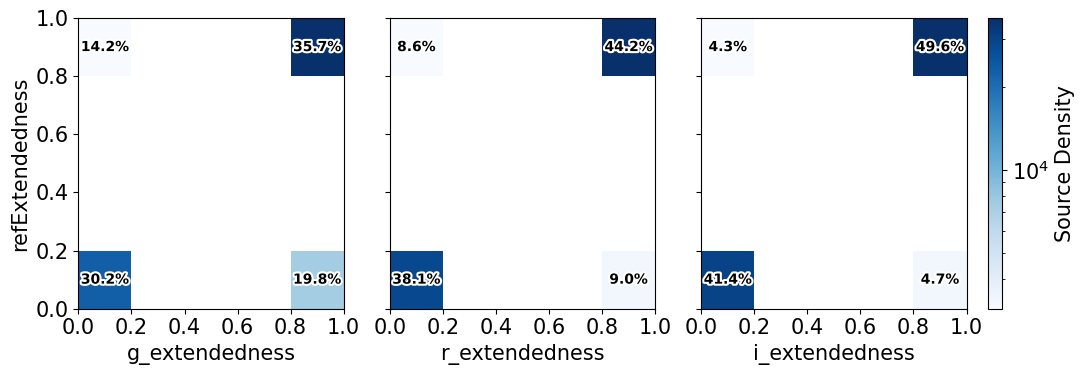

In [12]:
x_names = [f'{b}_extendedness' for b in bands]
y_names = ['refExtendedness'] * 3

plot_density_comparison(table, x_names, y_names, n_bins=5)
plt.show()

> **Figure 2:** Comparison between reference-band and per-band `extendedness` parameters. The color scale represents source density across the four discrete classification states: (0, 0), (1, 1), (0, 1), and (1, 0). Note that the flux-based `extendedness` parameter is binary, and the percentage of the total population in each cell is annotated. The majority of sources exhibit consistent classifications between individual bands and the reference band. The highest level of agreement is observed in the $i$ band, followed by the $r$ and $g$ bands, consistent with the reference band selection priority ($i→r→z→y→g→u$).

#### 3.1.3. Magnitude distributions

Examine the magnitude distributions of stars (`extendedness` = 0) and galaxies (`extendedness` = 1) across the $g,r,i$ bands.

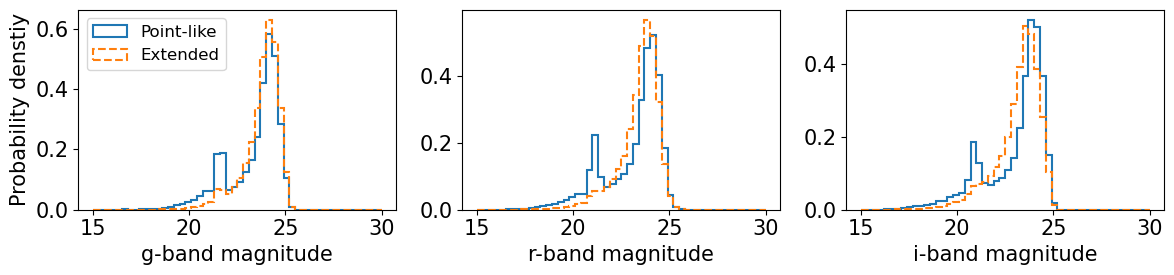

In [13]:
fig, axes = plt.subplots(1,3, figsize=(12, 3))

for band, ax in zip(bands, axes.flatten()):
    is_star = table[f'{band}_extendedness'] == 0
    
    ax.hist(table[f'{band}_psfMag'][is_star],
            bins=50, range=(15, 30), density=True,
            histtype='step', linewidth=1.5, label='Point-like'
    )
    
    ax.hist(table[f'{band}_cModelMag'][~is_star],
            bins=50, range=(15, 30), density=True,
            histtype='step', linestyle='--', linewidth=1.5, label='Extended'
    )

    ax.set_xlabel(f'{band}-band magnitude')
    
    if band == 'g':
        ax.set_ylabel('Probability denstiy')
        ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

> **Figure 3:** Magnitude distributions for star-like (blue solid lines) and galaxy-like (orange dashed lines) sources in the $g,r,i$ bands. Point sources are characterized by their `PSF` magnitudes, while extended sources use `cModel` magnitudes. The bump near 21 mag in the stellar distribution corresponds to red clump stars in the Fornax dSph.

### 3.2. Size-based extendedness

This parameter provides a continuous metric for star-galaxy separation by comparing the resolved size of a source to the local PSF. The classification relies on the "trace" of the adaptive moments matrix, defined as: $T=Ixx + Iyy$, where $Ixx$ and $Iyy$ are the second-order moments of the source's intensity distribution. $T$ serves as a robust, model-independent measure of the square of the radius. 

The $\chi^{2}$ statistic quantifies the extendedness by calculating the squared difference between the source's measured size and the expected PSF's size at the source's location, normalized by a power of the PSF size. This ensures the deviation is scaled appropriately relative to the local image quality. The output is mapped onto a scale from 0 to 1, representing the probability of being a galaxy: {band}_`sizeExtendedness` $= 1 - e^{-0.5\chi^{2}}$.

#### 3.2.1. Distribution of `sizeExtendedness`

Examine the distribution of the `sizeExtendedness` parameter across the $g,r,i$ bands. Values near 0 indicates the source's size is consistent with the PSF (likely a star), while values near 1 signifies the source is significantly more extended than the PSF (likely a galaxy).

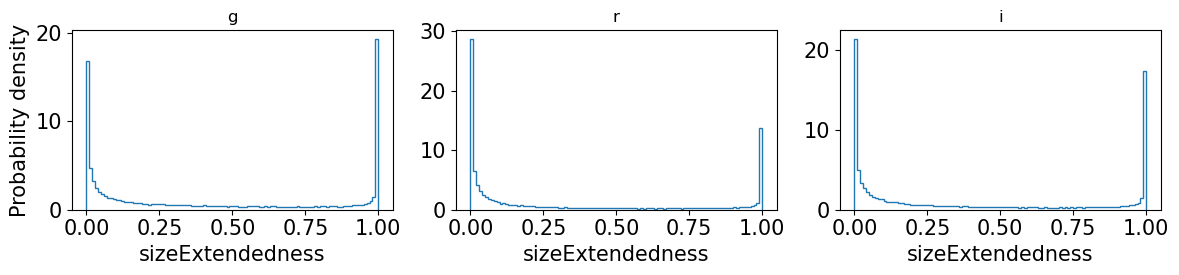

In [14]:
fig, axes = plt.subplots(1,3, figsize=(12, 3))

for band, ax in zip(bands, axes.flatten()):
    ax.hist(table[f'{band}_sizeExtendedness'], 
            bins=100, density=True, histtype='step'
    )
    ax.set_title(f'{band}')
    ax.set_xlabel(f'sizeExtendedness')
        
    if band == 'g':
        ax.set_ylabel('Probability density')

plt.tight_layout()
plt.show()

> **Figure 4:** In contrast to the binary, flux-based `extendedness` parameter, the `sizeExtendedness` parameter provides a continuous value ranging from 0 to 1, representing the degree of source extension.

#### 3.2.2. Comparison with `refSizeExtendedness`

Like the flux-based `extendedness` metric, size-based measurements are also provided both individual bands and the reference band. Compare the per-band values against the reference-band values.

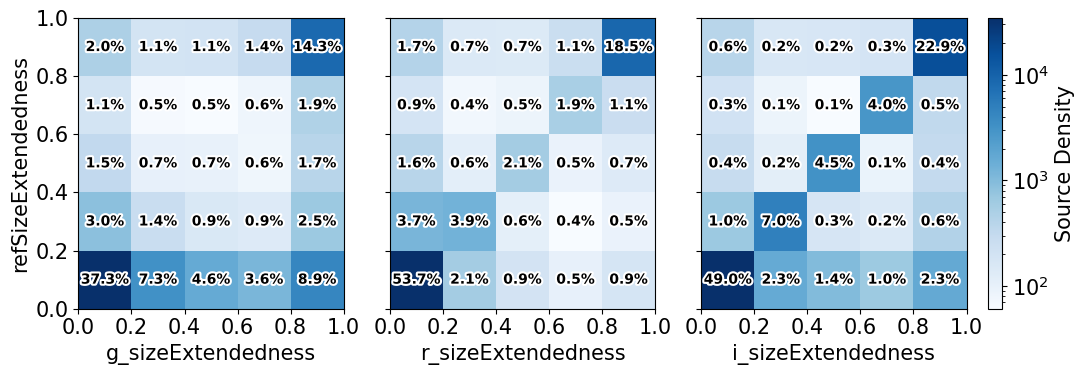

In [15]:
x_names = [f'{b}_sizeExtendedness' for b in bands]
y_names = ['refSizeExtendedness'] * 3

plot_density_comparison(table, x_names, y_names, n_bins=5)
plt.show()

> **Figure 5:** Comparison between reference-band and per-band `sizeExtendedness` parameters across the $g,r,i$ bands. The color scale represents source density, and the percentage of the total population in each cell is annotated. The majority of sources exhibit consistent values between individual bands and the reference band. The highest level of agreement is observed in the $i$ band, followed by the $r$ and $g$ bands, consistent with the reference band selection priority ($i→r→z→y→g→u$).

## 4. `extendedness` vs. `sizeExtendedness`

Compare the flux-based and size-based extendedness parameters.

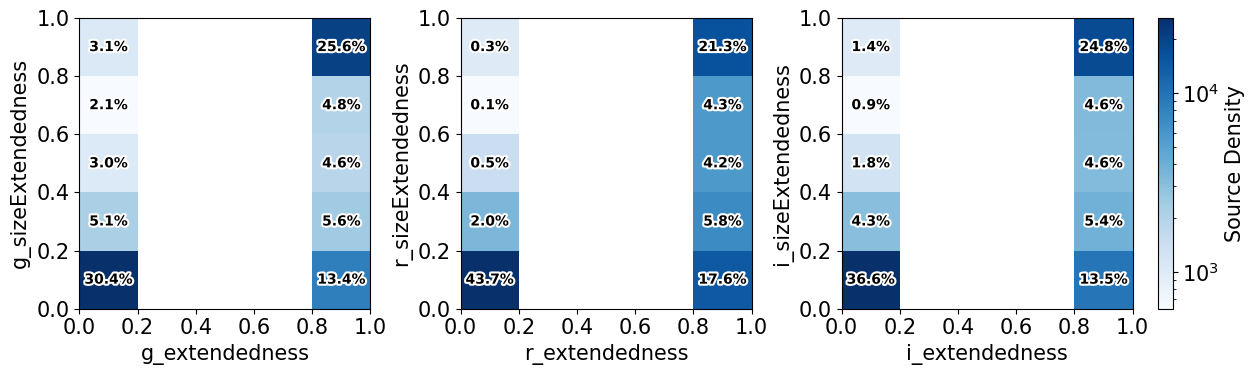

In [16]:
x_names = [f'{b}_extendedness' for b in bands]
y_names = [f'{b}_sizeExtendedness' for b in bands]

plot_density_comparison(table, x_names, y_names, n_bins=5, sharey=False, figsize=(14,4))
plt.show()

> **Figure 6:** Comparison between flux-based and size-based extendedness parameters across the $g,r,i$ bands. Despite the fundamental difference in their nature—one being a binary classifier and the other continuous—the majority of sources exhibit agreement in their morphological classification (56% in $g$, 65% in $r$, and 61.4% in $i$). The most notable discrepancy occurs where sources are classified as point-like by the size-based parameter but as extended by the flux-based parameter.

Examine the magnitude distributions for the sources exhibiting the most notable discrepancies in Figure 6.

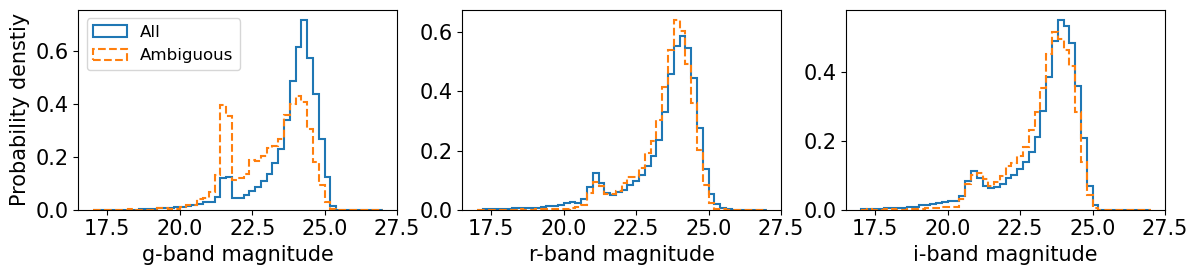

In [17]:
fig, axes = plt.subplots(1,3, figsize=(12, 3))

for band, ax in zip(bands, axes.flatten()):
    ambiguous_sources = (table[f'{band}_extendedness'] == 1) &\
                        (table[f'{band}_sizeExtendedness'] < 0.2)
    
    ax.hist(table[f'{band}_psfMag'],
            bins=50, range=(17, 27), density=True,
            histtype='step', linewidth=1.5, label='All'
    )
    
    ax.hist(table[f'{band}_psfMag'][ambiguous_sources],
            bins=50, range=(17, 27), density=True,
            histtype='step', linestyle='--', linewidth=1.5, label='Ambiguous'
    )

    ax.set_xlabel(f'{band}-band magnitude')
    
    if band == 'g':
        ax.set_ylabel('Probability denstiy')
        ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

> **Figure 7:** Normalized PSF magnitude distributions for the full sample (solid lines) compared to a subset of discrepant sources (dashed lines) across the $g,r,i$ bands. Ambiguous sources are defined here as those classified as extended by the flux-based metric (`extendedness` = 1) but identified as point-like by the size-based metric (`sizeExtendedness` < 0.2). The presence of a clear red clump feature at $\sim$21 mag within the distribution of ambiguous sources suggests that size-based metrics may offer more robust performance at least in this specific magnitude range.

## 5. Star-galaxy separation performance

This section explores the star-galaxy separation performance of the two morphological classifiers within the color-magnitude diagram (CMD) space

### 5.1. Using flux-based metric 

Construct ($g -r$, $g$) CMDs for sources classified as stars (`extendedness` = 0) and galaxies (`extendedness` = 1).  

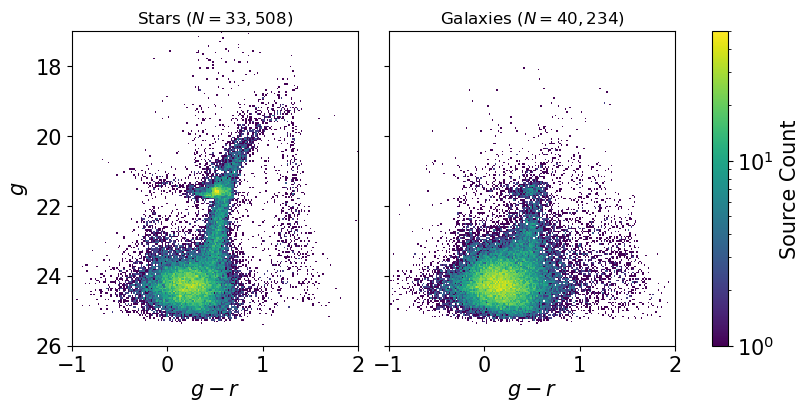

In [18]:
mag_range = [17, 26]
color_range = [-1, 2]
v_min, v_max = 1, 50 

is_star = table['refExtendedness'] == 0
color_gr = table['g_psfMag'] - table['r_psfMag']
mag_g = table['g_psfMag']

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, constrained_layout=True)

subsets = [is_star, ~is_star]
titles = ['Stars', 'Galaxies']

for ax, mask, title in zip(axes, subsets, titles):
    h = ax.hist2d(
        color_gr[mask], mag_g[mask], 
        bins=200, 
        range=[color_range, mag_range],
        norm=LogNorm(vmin=v_min, vmax=v_max)
    )
    
    ax.set_title(f'{title} ($N={mask.sum():,}$)', fontsize=12)
    ax.set_xlabel('$g - r$')
    
axes[0].set_ylabel('$g$')
axes[0].invert_yaxis()

fig.colorbar(h[3], ax=axes, label='Source Count', location='right')
plt.show()

> **Figure 8:** CMDs for stars (left) and galaxies (right) classified by the reference-band flux-based `extendedness` parameter. While the stellar CMD exhibits a clear Red Giant Branch (RGB), the red clump, the sub-giant branch, and the main sequence, along with Milky Way foreground/background stars, the galaxy CMD also shows faint traces of these same features, likely due to Fornax dSph member stars being misclassified as extended sources. This suggests that the binary classification becomes unreliable at faint magnitudes, where 'unresolved' sources suffer from increasing contamination by galaxies as signal-to-noise ratios decrease.

### 5.2. Using size-based metric

Recall that the `sizeExtendedness` parameter is provided as a continuous value ranging from 0 to 1, rather than a binary classification. Because there is no single established threshold for star-galaxy separation, this section examines ($g -r$, $g$) CMDs for populations defined by four different arbitrary thresholds.

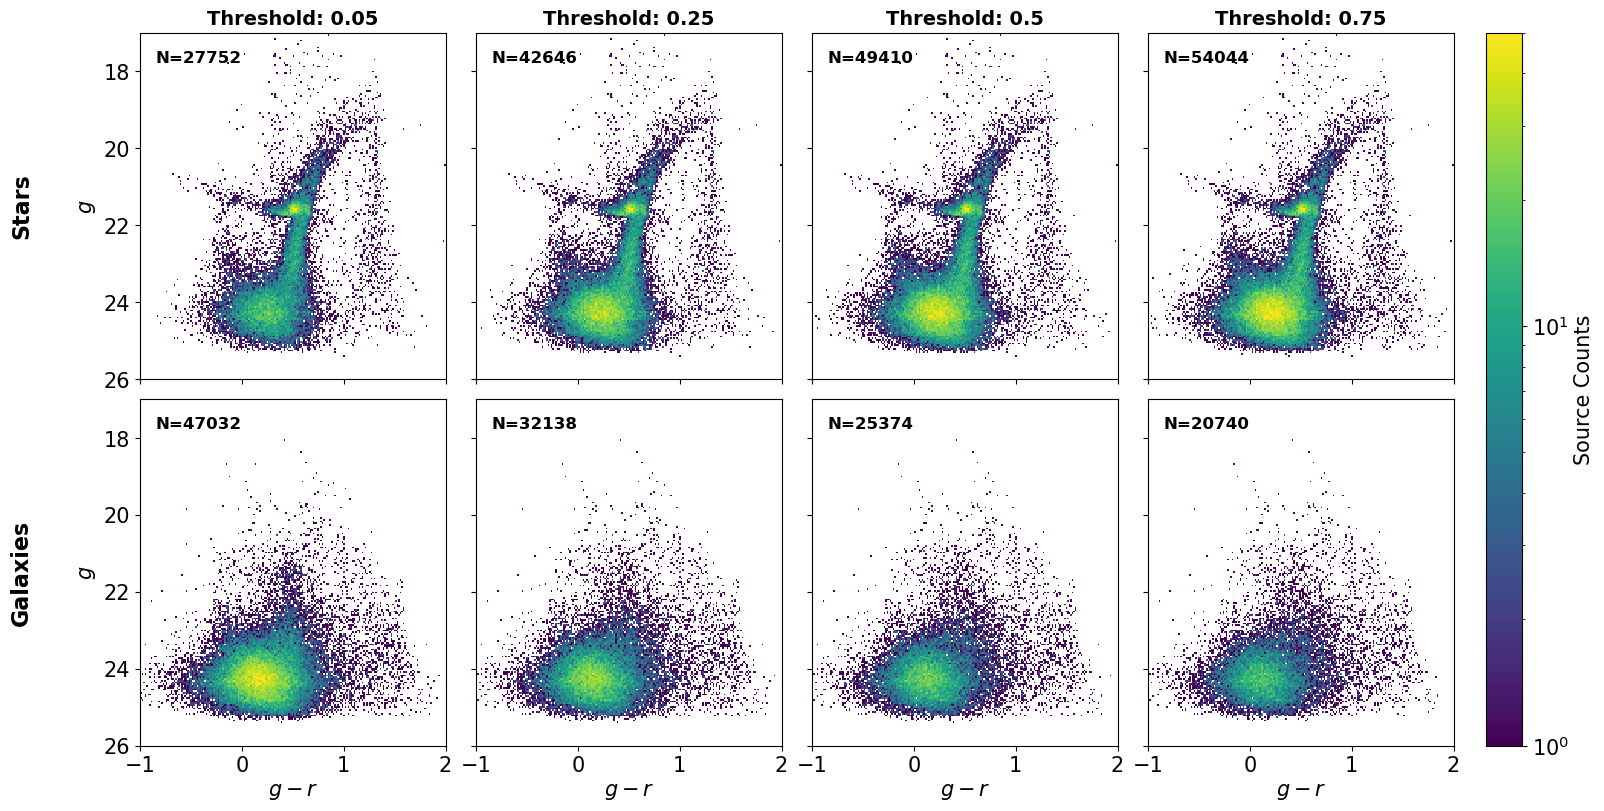

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True, constrained_layout=True)

thresholds = [0.05, 0.25, 0.5, 0.75]

for i, thres in enumerate(thresholds):
    is_star = table['refSizeExtendedness'] < thres
    
    plot_kwargs = {
        'bins': 200,
        'norm': LogNorm(vmin=v_min, vmax=v_max),
        'range': [color_range, mag_range]
    }

    color_stars = table['g_psfMag'][is_star] - table['r_psfMag'][is_star]
    mag_stars = table['g_psfMag'][is_star]
    im = axes[0, i].hist2d(color_stars, mag_stars, **plot_kwargs)
    
    n_stars = len(color_stars.compressed()) if hasattr(color_stars, 'mask') else len(color_stars)
    axes[0, i].text(0.05, 0.95, f'N={n_stars}', transform=axes[0, i].transAxes, 
                    va='top', ha='left', fontsize=12, fontweight='bold')

    color_gals = table['g_psfMag'][~is_star] - table['r_psfMag'][~is_star]
    mag_gals = table['g_psfMag'][~is_star]
    axes[1, i].hist2d(color_gals, mag_gals, **plot_kwargs)
    
    n_gals = len(color_gals.compressed()) if hasattr(color_gals, 'mask') else len(color_gals)
    axes[1, i].text(0.05, 0.95, f'N={n_gals}', transform=axes[1, i].transAxes, 
                    va='top', ha='left', fontsize=12, fontweight='bold')

    axes[0, i].set_title(f'Threshold: {thres}', fontsize=14, fontweight='bold')
    axes[1, i].set_xlabel('$g - r$')
    
    if i == 0:
        axes[0, i].set_ylabel('$g$')
        axes[1, i].set_ylabel('$g$')
    axes[0, i].invert_yaxis()

axes[0, 0].annotate('Stars', xy=(-0.35, 0.5), xycoords='axes fraction', 
                    rotation=90, va='center', ha='right', fontsize=16, fontweight='bold')
axes[1, 0].annotate('Galaxies', xy=(-0.35, 0.5), xycoords='axes fraction', 
                    rotation=90, va='center', ha='right', fontsize=16, fontweight='bold')

cbar = fig.colorbar(im[3], ax=axes, location='right', pad=0.02)
cbar.set_label('Source Counts')

plt.show()

> **Figure 9:** CMDs for stars (top row) and galaxies (bottom row) classified using `sizeExtendedness` thresholds of 0.05, 0.25, 0.5, and 0.75. As the threshold increases, the stellar sample becomes more inclusive while the galaxy sample becomes more restricted. Notably, none of these galaxy CMDs exhibit the prominent red clump contamination observed in the flux-based classification from Figure 8.

## 6. Usage notes and recommendations

- The flux-based `extendedness` parameter is optimized for use with the `Object` table, not with the `Source` table. This classification requires both a PSF flux and a galaxy-model flux (CModel) as inputs. Because the DP1 pipelines did not perform full galaxy modeling on single-visit images, the `extendedness` values in the `Source` table utilize a lower-fidelity proxy for galaxy flux. Consequently, morphological classification in the `Source` table should be treated with caution and is generally not recommended for sensitive star-galaxy separation.

- While both `extendedness` and `sizeExtendedness` are available for every individual filter in the `Object` table, most scientific applications should prioritize reference-band values (i.e., `refExtendedness` and `refSizeExtendedness`). These are derived from a designated filter chosen for its superior detection significance and measurement quality. Utilizing the reference-band classification ensures a single, robust morphological definition for each object, minimizing the risk of inconsistent classification across different wavebands.

- For sources where the flags for extendedness parameter are set for any failure, the corresponding extendedness values were not populated.